# Research Challenge

<div style="background-color: #f8d7da; border-left: 6px solid #ccc; margin: 20px; padding: 15px;">
    <strong>💡 Margaret Atwood:</strong> Every aspect of human technology has a dark side, including the bow and arrow.
</div>

## 🏅 Build your own model

It is time to go back to supervised machine learning problems.

You have been assigned one dataset from [MatBench](https://matbench.materialsproject.org) as introduced in the [Lecture slides](https://speakerdeck.com/aronwalsh/mlformaterials-challenge-25). You are free to choose and tune any machine-learning model, with any Python library, but it should be appropriate for the problem. For instance, [XGBoost](https://xgboost.readthedocs.io) could be a good starting starting point to build a regression model. You can refer back to earlier notebooks and repurpose code as needed.

You may reach the limits of computing processing power on Google Colab. Building a useful model with limited resources is a real-world skill. Using other free resources is allowed if you find an alternative service, as is running on your own computer. A model tracker such as [wandb](https://wandb.ai) could be helpful for advanced users. If you want to try a brute force approach, a library such as [Automatminer](https://hackingmaterials.lbl.gov/automatminer) may be of interest.

This notebook should be used for keeping a record of your model development, submission, and even your presentation. You are free to edit (add/remove/delete) or rearrange the cells as you see fit.

### Your details

In [29]:
import numpy as np

# Insert your values
Name = "Mark Zangwill" # Replace with your name
CID = 2198282 # Replace with your College ID (as a numeric value with no leading 0s)

# Set a random seed using the CID value
CID = int(CID)
np.random.seed(CID)

# Print the message
print("This is the work of " + Name + " [CID: " + str(CID) + "]\n")

# Define the available groups
groups = ['A', 'B', 'C', 'D', 'E']

# Select a group based on the seeded random state
challenge_group = np.random.choice(groups)

# Print the challenge code
print("Your challenge code is " + challenge_group)

This is the work of Mark Zangwill [CID: 2198282]

Your challenge code is C


## Problem statement
You have been assigned one dataset from the [list](https://matbench.materialsproject.org/Benchmark%20Info/matbench_v0.1/) on [MatBench](https://matbench.materialsproject.org). You should state what problem you are trying to solve and comment on the best-performing model in the benchmark.

In [30]:
# Spare cell




## Data preparation

Check the data distribution and apply appropriate pre-processing steps as required.

In [31]:
# Installation of libraries
!pip install matminer # Datasets and featurisation

In [32]:
# Get dataset info from matminer
from matminer.datasets import get_all_dataset_info
from matminer.datasets import load_dataset

# Detailed on https://hackingmaterials.lbl.gov/matminer/dataset_summary.html
# Uncomment the info line for your assigned challenge code

  # A
#info = get_all_dataset_info("matbench_dielectric")

  # B
#info = get_all_dataset_info("matbench_expt_gap")

  # C
info = get_all_dataset_info("matbench_expt_is_metal")

  # D
#info = get_all_dataset_info("matbench_glass")

  # E
#info = get_all_dataset_info("matbench_steels")

# Check the dataset information
print(info)

Dataset: matbench_expt_is_metal
Description: Matbench v0.1 test dataset for classifying metallicity from composition alone. Retrieved from Zhuo et al. supplementary information. Deduplicated according to composition, ensuring no conflicting reports were entered for any compositions (i.e., no reported compositions were both metal and nonmetal). For benchmarking w/ nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.
Columns:
	composition: Chemical formula.
	is_metal: Target variable. 1 if is a metal, 0 if nonmetal.
Num Entries: 4921
Reference: Y. Zhuo, A. Masouri Tehrani, J. Brgoch (2018) Predicting the Band Gaps of Inorganic Solids by Machine Learning J. Phys. Chem. Lett. 2018, 9, 7, 1668-1673 
 https//:doi.org/10.1021/acs.jpclett.8b00124.
Bibtex citations: ["@Article{Dunn2020,\nauthor={Dunn, Alexander\nand Wang, Qi\nand Ganose, Alex\nand Dopp, Daniel\nand Jain, Anubhav},\ntitle={Benc

In [33]:
# Load your dataset into a pandas DataFrame
df = load_dataset("matbench_expt_is_metal")

print(df)

            composition  is_metal
0              Ag(AuS)2      True
1            Ag(W3Br7)2      True
2      Ag0.5Ge1Pb1.75S4     False
3     Ag0.5Ge1Pb1.75Se4     False
4                Ag2BBr      True
...                 ...       ...
4916             ZrTaN3     False
4917               ZrTe      True
4918             ZrTi2O      True
4919             ZrTiF6      True
4920               ZrW2      True

[4921 rows x 2 columns]


In [34]:
df.describe()

,composition,is_metal
count,4921,4921
unique,4921,2
top,ZrW2,False
freq,1,2470


Where middle column is the "composition" column, with all 4921 being unique. The last column beign the output, unique being two since outputs are either true or false, depending on whenther metal or non.

Choose relevant features, which may be based on composition or structure, depending on your problem. [matminer](https://hackingmaterials.lbl.gov/matminer/) is a good place to start.

###Materials Featurization

In [35]:
#download ElementEmbedings
!pip install elementembeddings

Method for featurizing dataframe with chosen embeding scheme (e.g. magpie) and stats (e.g. minpool)

In [36]:
# Featurise all chemical compositions
from elementembeddings.composition import composition_featuriser

def featurise(dataframe, embedding, stats):

  if stats  == "all":
    stats = ["mean"] #leaving out to make testing faster "maxpool", "variance","minpool", "maxpool", "sum"
  else:
    stats = stats

  featurised_df = composition_featuriser(dataframe["composition"], embedding=embedding, stats=stats)

  # Convert "is_metal" column to integer labels (0, 1)
  dataframe['is_metal'] = dataframe['is_metal'].astype(int)
  featurised_df['is_metal'] = dataframe['is_metal']

  # Define feature matrices and target variable
  cols_to_drop = ['is_metal', 'formula']

  X = featurised_df.drop(columns=cols_to_drop, errors='ignore').values # leaving only featurized composition left
  y = dataframe['is_metal'].values  # Target variable

  return featurised_df, X, y

In [37]:
featurised_df, X,  y = featurise(df, "magpie", "all")

print(featurised_df.iloc[:2, :4])

Featurising compositions...


100%|██████████| 4921/4921 [00:26<00:00, 183.92it/s]


Computing feature vectors...


100%|██████████| 4921/4921 [00:00<00:00, 154207.19it/s]


      formula  mean_Number  mean_MendeleevNumber  mean_AtomicWeight
0    Ag(AuS)2    47.400000                  74.6         113.186268
1  Ag(W3Br7)2    46.714286                  81.0         110.931629


In [38]:
print(featurised_df.shape)

(4921, 24)


In [39]:
print(X.shape)

(4921, 22)


pick the best stats to use. e.g. mean or variance or ...

embedding scheme could also be tested...Use decsion tree since faster

In [40]:
#determine the most important features for a given ml model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  #ensemble models will generaly perfrom better
import matplotlib.pyplot as plt
import numpy as np

models = (DecisionTreeClassifier()) #, RandomForestClassifier()) #establish models which will be used

def feature_ranking(model, X, y, featurised_df):

  model.fit(X, y)
  importances = model.feature_importances_

  feature_cols = [col for col in featurised_df.columns if col not in ['is_metal', 'formula']]
  feature_names = np.array(feature_cols)

  # Get indices to sort importances in descending order
  indices = np.argsort(importances)[::-1]

  # Sort feature names and importances
  sorted_feature_names = feature_names[indices]
  sorted_importances = importances[indices]

  # return X in descending importance order
  X = X[:, indices]

  return X

In [41]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

for model in models:

  X = feature_ranking(model, X, y, featurised_df)

  min_features_to_select = 1  # Minimum number of features to consider
  cv = StratifiedKFold(2) # using lower fold numbers to run quicker

  rfecv = RFECV(  #apply recursive feature elimination with cross-validation
      estimator=model,
      step=1,
      cv=cv,
      scoring= "roc_auc", # Corrected from 'roc_auc_score' to 'roc_auc'
      min_features_to_select=min_features_to_select,
      n_jobs=2,
  )
  rfecv.fit(X, y)

  print(f"Optimal number of features for {model.__class__.__name__} : {rfecv.n_features_}")

TypeError: 'DecisionTreeClassifier' object is not iterable

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    key: value
    for key, value in rfecv.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
}
cv_results = pd.DataFrame(data)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith cross-validation")
plt.show()

In [ ]:
#Reduce X to first 20 features for faster computation
X = X[:, :10]
print(X.shape) # verify new size of array

Train, validate and test your model. Make sure to do proper data splits and to consider the hyperparamaters of your model.

<details>
<summary>Note on the ROC-AUC classification metric</summary>
There is one metric we didn't cover but is used in Matbench. In binary classification models, the ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score can be used to evaluate performance. It quantifies the ability of the model to distinguish between positive and negative instances across different decision thresholds. A higher ROC-AUC score (ranging from 0.5 to 1) indicates better performance, with 1 representing a perfect classifier and 0.5 indicating performance no better than random chance. There is a more detailed discussion here: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc.

The metric can be calculated using the `roc_auc_score` function from the `sklearn.metrics` module, e.g.

```python
from sklearn.metrics import roc_auc_score

# Assuming you have true labels (y_true) and predicted probabilities (y_pred_prob)
y_true = [...]  
y_pred_prob = [...]  

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Display the result
print(f'ROC-AUC Score: {roc_auc:.4f}')
```
</details>

Train, validate and test your model. Make sure to do proper data splits and to consider the hyperparamaters of your model.

<details>
<summary>Note on the ROC-AUC classification metric</summary>
There is one metric we didn't cover but is used in Matbench. In binary classification models, the ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score can be used to evaluate performance. It quantifies the ability of the model to distinguish between positive and negative instances across different decision thresholds. A higher ROC-AUC score (ranging from 0.5 to 1) indicates better performance, with 1 representing a perfect classifier and 0.5 indicating performance no better than random chance. There is a more detailed discussion here: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc.

The metric can be calculated using the `roc_auc_score` function from the `sklearn.metrics` module, e.g.

```python
from sklearn.metrics import roc_auc_score

# Assuming you have true labels (y_true) and predicted probabilities (y_pred_prob)
y_true = [...]  
y_pred_prob = [...]  

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Display the result
print(f'ROC-AUC Score: {roc_auc:.4f}')
```
</details>

Can see that fewer than the original 132 features are produce better results and will be less computationaly demanding when doing full training and tuning of hyperparameters on large cross validation

## Model selection, testing and training

Define your model and justify your choice based on the problem and available data. You can look back at earlier notebooks and investigate other examples online including in [scikit-learn](https://scikit-learn.org).

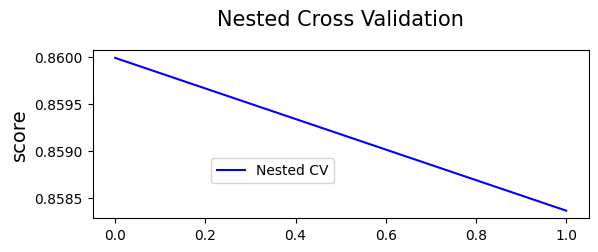

In [43]:
import numpy as np
from matplotlib import pyplot as plt

from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

dTC = DecisionTreeClassifier()

# Number of random trials
NUM_TRIALS = 2

# Set up possible values of parameters to optimize over
p_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"]
}

nested_scores = np.zeros(NUM_TRIALS)

# Loop for each trial
for i in range(NUM_TRIALS):
    # Choose cross-validation techniques for the inner and outer loops,
    # independently of the dataset.
    # E.g "GroupKFold", "LeaveOneOut", "LeaveOneGroupOut", etc.
    inner_cv = KFold(n_splits=2, shuffle=True, random_state=i)
    outer_cv = KFold(n_splits=2, shuffle=True, random_state=i)

    # Nested CV with parameter optimization
    dTC = GridSearchCV(estimator=dTC, param_grid=p_grid, cv=inner_cv)
    dTC.fit(X, y) # Fit the inner GridSearchCV
    nested_score = cross_val_score(dTC.best_estimator_, X=X, y=y, cv=outer_cv)
    nested_scores[i] = nested_score.mean()

# Plot scores on each trial for nested and non-nested CV
plt.figure()
plt.subplot(211)
(nested_line,) = plt.plot(nested_scores, color="b")
plt.ylabel("score", fontsize="14")
plt.legend(["Nested CV"],
    bbox_to_anchor=(0, 0.4, 0.5, 0)
)
plt.title(
    "Nested Cross Validation",
    x=0.5,
    y=1.1,
    fontsize="15",
)
plt.show()


To conduct hyperparameter optimization, nested crossed validation is requred as to not leak data, giving optimisitic results. This involves having two loops; an inner and outer. The inner is where featurization is done as well as hyperparameter optimization. the outer does test.

Train, validate and test your model. Make sure to do proper data splits and to consider the hyperparamaters of your model.

<details>
<summary>Note on the ROC-AUC classification metric</summary>
There is one metric we didn't cover but is used in Matbench. In binary classification models, the ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score can be used to evaluate performance. It quantifies the ability of the model to distinguish between positive and negative instances across different decision thresholds. A higher ROC-AUC score (ranging from 0.5 to 1) indicates better performance, with 1 representing a perfect classifier and 0.5 indicating performance no better than random chance. There is a more detailed discussion here: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc.

The metric can be calculated using the `roc_auc_score` function from the `sklearn.metrics` module, e.g.

```python
from sklearn.metrics import roc_auc_score

# Assuming you have true labels (y_true) and predicted probabilities (y_pred_prob)
y_true = [...]  
y_pred_prob = [...]  

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Display the result
print(f'ROC-AUC Score: {roc_auc:.4f}')
```
</details>

In [ ]:
# Spare cell




## Model analysis and discussion

How well does your final model perform? Think of metrics and plots that are useful to dig a little deeper.

Compare against the best-performing model on the [MatBench](https://matbench.materialsproject.org) leaderboard.  With limited resources, don't expect to match this performance, but you should do better than a baseline model.

In [ ]:
# Spare cell




## Large Language Model (LLM) usage declaration

Acknowledge use of a generative model during your assignment. Points to consider:

* State which LLM (e.g. GPT-4, Gemini, Co-Pilot)

* Specify tasks (e.g. summarising research or code snippets)

* Were any limitations/biases noted?

* How did you ensure ethical use?

In [ ]:
# Spare cell


